# ML2

## Answer the questions

Найдите аналитическое решение задачи регрессии. Используйте векторную форму уравнения.

$$ X \in \mathbb{R}^{N,d}$$
$$ y \in \mathbb{R}^{N}$$
$$ w \in \mathbb{R}^{d}$$

$$ \hat{y} = wX$$

$$ L = (y-\hat{y})^2 \rightarrow   (y-wX)^T (y-wX)$$

$$ L = y  y^T - y^T wX - y wX^T + wX  w^T X^T$$


$$\frac{\partial L}{\partial w}= {\partial \left(y  y^T - y^T wX - y w^TX^T + wX  w^T X^T \right)}/{\partial w}  $$

 Так как

$$y^T wX = (y^TwX)^T = yw^TX^T$$

Делаем замену

Вычисляем  производную

$$ \partial \left(wX  w^T X^T\right)/\partial w = 2w X^TX$$


$$\frac{\partial L}{\partial w}= \left(0 - 2 yX^T + 2w X^T X \right) =0$$

$$ w = \left(0 - 2yX^T + 2w X^T X \right) =0$$

Итог

$$ w = yX^T(X^TX)^{-1}$$

What changes in the solution when L1 and L2 regularizations are added to the loss function.

Короче ~~бля~~ там добавляется в функцию потерь ещё один член. В зависимости от выбора регуляризации. Ща нарисую формулки.

$$ L = ||y-\hat{y}||^2 + \lambda ||w||^2$$

Это L2 регуляризация где добавляется квадрат(эвклидово расстояние) Тупо скаляр)

Расскроем скобочки как настоящие математики двадвать первого века!!

$$ L = (y-Xw)^T(y-Xw) + \lambda w^Tw$$

Теперь очень очень грамотно берём производную чтобы приравнять её к нулю(найти минимум)

$$\nabla = d(L)/dw  = 0$$

$$\nabla = -2y^TX +2wX^TX + 2\lambda w = 0$$

$$w = yX^T (X^TX+\lambda I)^{-1}$$

L1 Регуляризация. Расчёт градиента.

Параметр регуляризации Regularization Strength (лямбда)

$$ L = ||y-\hat{y}||^2 + \lambda \sum_{i=1}^d|w|$$

$$ L = (y-Xw)^T(y-Xw) + \lambda |w|$$

$$\nabla = d(L)/dw  = 0$$

$$\nabla = -2y^TX +2wX^TX + 2\lambda * sign(w) = 0$$

$$w = yX^T (X^TX+\lambda I * sign(w))^{-1}$$

Объясните, почему для выбора объектов часто используется регуляризация L1. Почему после подгонки модели многие значения весов равны 0?

НЕВЕРНО. L2 регуляризация часто используется для выбора признаков, потому что она вносит сумму весов в функцию потерь!!  
Почему многие веса становятся равными нулю после того, как модель подстроилась? Дело в том,что если веса малополезных признаков в нуле, то функция потерь меньше!!!!!!!!!!!!!!!!!!!!!!!! 

Объясните, как вы можете использовать одни и те же модели (линейная регрессия, гребень и т.д.), но при этом Приспосабливать их к нелинейным зависимостям.

Оно всё само, благодаря градиентному спуску, приспосабливает к безграничному числу признаку. Для того чтобы использовать линейные модели (Linear Regression, Ridge, Lasso) для моделирования нелинейных зависимостей, необходимо выполнить нелинейное преобразование признаков. Основная идея заключается в том, что модель остается «линейной» относительно своих параметров (коэффициентов), но работает в новом, трансформированном пространстве признаков, где связь с целевой переменной становится линейной. 

## Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler, StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet, Lasso
from sklearn.tree import DecisionTreeRegressor
import collections

## 2. Introduction — make all the preprocessing staff from the previous lesson

### Read Train and Test Parts.

In [2]:
df = pd.read_json('data/train.json')


In [3]:
df.columns

Index(['bathrooms', 'bedrooms', 'building_id', 'created', 'description',
       'display_address', 'features', 'latitude', 'listing_id', 'longitude',
       'manager_id', 'photos', 'price', 'street_address', 'interest_level'],
      dtype='object')

In [4]:
df.head(10)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low
16,1.0,3,300d27d8ba2adbcbc8c6f2bcbc1c6f9d,2016-06-28 05:59:06,This spectacular converted 3 bed apartment all...,East 16th Street,"[Doorman, Elevator, Loft, Dishwasher, Hardwood...",40.7348,7226687,-73.9865,30a7951cfc21240e8c46b2d079d292e5,[https://photos.renthop.com/2/7226687_4ea22bf1...,7200,145 East 16th Street,low
18,2.0,3,0d01cabe55fa5192cdbcabd5c585c1ea,2016-06-08 06:21:36,AMAZING DEAL!! BRAND NEW RENOVATIONS IN THIS H...,East 13th Street,"[Fireplace, Laundry in Unit, Dishwasher, Hardw...",40.7302,7126989,-73.9826,9f39caedae295bf81e67463e6fd0af40,[https://photos.renthop.com/2/7126989_a74ab3da...,6000,410 East 13th Street,low
19,1.0,0,d48767c37a934daaf0bbb0e58c755d0c,2016-06-05 05:28:22,No Fee Large Renovated Sun Splashed Studio. Wa...,York Avenue,"[Elevator, Laundry in Building, Dishwasher, Ha...",40.7769,7114138,-73.9467,9cbfa7a31ae9dfba70b4383636d99788,[https://photos.renthop.com/2/7114138_68d035c3...,1945,1661 York Avenue,high
23,0.0,1,d1ca33a2853e64fad6e4009d5d5d168f,2016-06-09 04:42:03,Extra large one bedroom apartment located in P...,E 19 Street,[Hardwood Floors],40.7346,7131094,-73.9811,b89e62bf8cdc98e9fb8b97d9bc627197,[https://photos.renthop.com/2/7131094_2117d8a9...,2435,346 E 19 Street,low
32,3.0,3,5f35dc2f0191baf109221752e6ee0c48,2016-06-28 03:26:18,Listed: 06/26/16<br /><br />Available:...,Hicks Street,"[Cats Allowed, Dogs Allowed]",40.6990,7224815,-73.9943,d5d246c9d9d4e7079e5a0fc962d2f1a7,[https://photos.renthop.com/2/7224815_8ff8a811...,6850,94 Hicks Street,low


In [5]:
df['features'] = df['features'].apply(lambda x: [elem.strip('[]\'\" ').lower() for elem in x])

In [6]:
df['features']

4         [dining room, pre-war, laundry in building, di...
6         [doorman, elevator, laundry in building, dishw...
9         [doorman, elevator, laundry in building, laund...
10                                                       []
15        [doorman, elevator, fitness center, laundry in...
                                ...                        
124000              [elevator, dishwasher, hardwood floors]
124002    [common outdoor space, cats allowed, dogs allo...
124004    [dining room, elevator, pre-war, laundry in bu...
124008    [pre-war, laundry in unit, dishwasher, no fee,...
124009    [dining room, elevator, laundry in building, d...
Name: features, Length: 49352, dtype: object

### Get all values in each list and collect the result in one huge list for the whole dataset. You can use DataFrame.iterrows().

In [7]:
big_list = []
for elem in df['features']:
    for item in elem:
        big_list.append(item)

### How many unique values does a result list contain?

In [8]:
unique_features = set()
for row in df['features']:
    for elem in row:
        unique_features.add(elem)
# unique_features

In [9]:
len(unique_features)

1294

### Let's get acquainted with the new library — Collections. With this package you could effectively get quantity statistics about your data

### Count the most popular functions from our huge list and take the top 20 for this moment.

In [10]:
cntr = collections.Counter(big_list)
cntr.most_common(20)

[('elevator', 26273),
 ('hardwood floors', 23558),
 ('cats allowed', 23540),
 ('dogs allowed', 22035),
 ('doorman', 20967),
 ('dishwasher', 20806),
 ('laundry in building', 18944),
 ('no fee', 18079),
 ('fitness center', 13257),
 ('laundry in unit', 9435),
 ('pre-war', 9149),
 ('roof deck', 6555),
 ('outdoor space', 5270),
 ('dining room', 5150),
 ('high speed internet', 4299),
 ('balcony', 3058),
 ('swimming pool', 2730),
 ('new construction', 2608),
 ('terrace', 2313),
 ('exclusive', 2167)]

In [11]:
usual_feat = []
for item in cntr.most_common(20):
    usual_feat.append(item[0])
usual_feat


['elevator',
 'hardwood floors',
 'cats allowed',
 'dogs allowed',
 'doorman',
 'dishwasher',
 'laundry in building',
 'no fee',
 'fitness center',
 'laundry in unit',
 'pre-war',
 'roof deck',
 'outdoor space',
 'dining room',
 'high speed internet',
 'balcony',
 'swimming pool',
 'new construction',
 'terrace',
 'exclusive']

### Now create 20 new features based on the top 20 values: 1 if the value is in the "Feature" column, otherwise 0.

In [12]:
for item in usual_feat:
    df[item] = df['features'].apply(lambda x: 1 if item in x else 0)

In [13]:
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,pre-war,roof deck,outdoor space,dining room,high speed internet,balcony,swimming pool,new construction,terrace,exclusive
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[dining room, pre-war, laundry in building, di...",40.7108,7170325,-73.9539,...,1,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[doorman, elevator, laundry in building, dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[doorman, elevator, laundry in building, laund...",40.7575,7158677,-73.9625,...,0,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[doorman, elevator, fitness center, laundry in...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0


In [14]:
df.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price,elevator,hardwood floors,cats allowed,dogs allowed,...,pre-war,roof deck,outdoor space,dining room,high speed internet,balcony,swimming pool,new construction,terrace,exclusive
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04,49352.000000,49352.000000,49352.000000,49352.000000,...,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000,49352.000000
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03,0.532339,0.477346,0.476982,0.446486,...,0.185383,0.132821,0.106784,0.104352,0.087109,0.061963,0.055317,0.052845,0.046867,0.043909
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04,0.498958,0.499492,0.499475,0.497133,...,0.388612,0.339385,0.308841,0.305720,0.281997,0.241091,0.228600,0.223726,0.211357,0.204895
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Extend our feature set with 'bathrooms', 'bedrooms' and create a special variable feature_list with all feature names. Now we have 22 values. All models should be trained on these 22 features.

In [15]:
feature_list = usual_feat.copy()
feature_list.append('bathrooms')
feature_list.append('bedrooms')
feature_list

['elevator',
 'hardwood floors',
 'cats allowed',
 'dogs allowed',
 'doorman',
 'dishwasher',
 'laundry in building',
 'no fee',
 'fitness center',
 'laundry in unit',
 'pre-war',
 'roof deck',
 'outdoor space',
 'dining room',
 'high speed internet',
 'balcony',
 'swimming pool',
 'new construction',
 'terrace',
 'exclusive',
 'bathrooms',
 'bedrooms']

## Models implementation — Linear regression

Implement a Python class for a linear regression algorithm with two basic methods — fit and predict. Use stochastic gradient descent (SGD) to find optimal model weights. For better understanding, we recommend implementing separate versions of the algorithm with the analytical solution and non-stochastic gradient descent under the hood.

In [16]:
def loss_fn(y1,y2):
    return np.mean((y1-y2)**2)

def RSq(w):
    return np.sum(np.abs(w))

class MyLinearRegressionAnalytic:
    def __init__(self):
        pass
    def fit(self,X,y, fit_intersept = True):

        X_mean = np.mean(X,axis=0)
        y_mean = np.mean(y,axis=0)
        if fit_intersept:
            X = X - np.mean(X,axis=0)
            y = y - np.mean(y,axis=0)

        tran_x = X.T                            # d,N
        y_prod_X = tran_x @ y                   # d,N * N,1 = d,1
        inv_x = np.linalg.inv(tran_x @ X)       # d,N * N,d = d,d
        self.w = inv_x @ y_prod_X               # d,d * d,1 = d,1
        if fit_intersept:
            self.b = y_mean - X_mean @ self.w   # 1,1 = N,1 - N,d * d,1 => 1,1 - 1,d * d,1
        else:
            self.b = 0
        return self
    
    def fit_grad(self,X,y,n_epoch=5000,lr=0.01,batch = 100, fit_intersept = True):
        np.random.seed(21)
        self.w = np.random.random(len(X.columns))
        if fit_intersept:
            self.b = np.random.random()
        else:
            self.b = 0
        for epoch in range(1,n_epoch+1):
            sample = X.sample(batch)                                # N,d * d,1 = N,1
            out = sample @ self.w + self.b                          # 50,d * d,1 = 50,1

            loss = loss_fn(y[sample.index].values,out)        
            error = out-y[sample.index].values 

            self.w = self.w - lr*(sample.T @ error) / batch         #d,1 = d,1 - const *(d,50 * (50,1-50,1)) / N
            if fit_intersept:
                self.b = self.b - lr *np.mean(error)

            if epoch % 100 == 0 or epoch == 1:
                print(f'epoch {epoch} loss {loss:.2f}')
        return self
    
    def predict(self,X_test):
        y_pred = X_test @self.w + self.b                # N,1 = N,d * d,1 + b
        return y_pred

### Очистка от выбросов

In [17]:
q95 = df['price'].quantile(0.95)
q05 = df['price'].quantile(0.05)
df = df.drop(index=df[df['price'] > q95].index)
df = df.drop(index=df[df['price'] < q05].index)

In [18]:

X_train,X_test,y_train,y_test = train_test_split(
    df[feature_list],
    df['price'],
    test_size=0.2,
    random_state=1
)

In [19]:
model = MyLinearRegressionAnalytic()
model.fit(X=X_train,y=y_train)
y_pred = model.predict(X_test=X_test)

In [20]:
mean_absolute_error(y_true=y_test,y_pred=y_pred)

597.9566521239968

In [21]:
y_pred.head()

83421     2629.668274
114625    3021.345048
109600    2490.425417
62053     2943.942616
119786    4792.095944
dtype: float64

In [22]:
model_grad = MyLinearRegressionAnalytic()
model_grad.fit_grad(X_train,y_train)
y_pred_grad = model_grad.predict(X_test)

epoch 1 loss 12900102.59
epoch 100 loss 819402.96
epoch 200 loss 672812.08
epoch 300 loss 891019.96
epoch 400 loss 686283.60
epoch 500 loss 605553.94
epoch 600 loss 552122.04
epoch 700 loss 528897.67
epoch 800 loss 589045.09
epoch 900 loss 491609.01
epoch 1000 loss 680068.41
epoch 1100 loss 656648.39
epoch 1200 loss 584083.64
epoch 1300 loss 792178.17
epoch 1400 loss 714041.34
epoch 1500 loss 600740.50
epoch 1600 loss 637397.38
epoch 1700 loss 665665.23
epoch 1800 loss 620577.28
epoch 1900 loss 641903.55
epoch 2000 loss 636255.91
epoch 2100 loss 646955.70
epoch 2200 loss 514522.29
epoch 2300 loss 537180.10
epoch 2400 loss 609428.55
epoch 2500 loss 726838.83
epoch 2600 loss 773089.11
epoch 2700 loss 726821.58
epoch 2800 loss 468350.37
epoch 2900 loss 644384.38
epoch 3000 loss 463693.64
epoch 3100 loss 420367.53
epoch 3200 loss 600420.25
epoch 3300 loss 438090.48
epoch 3400 loss 624977.81
epoch 3500 loss 747487.28
epoch 3600 loss 624968.59
epoch 3700 loss 616264.27
epoch 3800 loss 585696

In [23]:
y_pred_grad

83421     2616.271927
114625    3016.878807
109600    2484.789981
62053     2975.123990
119786    4813.445906
             ...     
20531     2561.598356
100274    4854.767601
123768    3342.627610
116764    4078.995560
29106     2773.481086
Length: 8923, dtype: float64

In [24]:
mean_absolute_error(y_true=y_test,y_pred=y_pred_grad)

598.2179749814529

### What is determenistic model? Make SGD determenistic.

Детерминистическая модель — это математическая или компьютерная модель, в которой отсутствует случайность, а все входные параметры приводят к однозначному результату. Это означает, что при одинаковых исходных данных система всегда будет выдавать одинаковый результат.

Сделать модель детермининорованной можно благодаря внесению в неё "начальный сид" - число используя которое воспроизводится случайность  
Добавил в код #np.random.seed(21)

3. Define the R squared (R2) coefficient and implement a function to calculate it.

In [25]:
def myr2_score(y_true,y_pred):
    if len(y_true) == 0 or len(y_pred) == 0:
        return None
    y_m = np.mean(y_true)
    SSres = np.sum((y_true - y_pred)**2) / len(y_true)
    SStot = np.sum((y_true - y_m)**2) / len(y_true)
    R2 = 1 - SSres/SStot

    return R2

In [26]:
print(f'MY R2_SCORE: {myr2_score(y_true=y_test,y_pred=y_pred):.2f}')

MY R2_SCORE: 0.51


4. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.


In [27]:
print('Analytical solve')
print(f'MAE: {mean_absolute_error(y_true=y_test,y_pred=y_pred):.2f}')
print(f'R2_SCORE: {r2_score(y_true=y_test,y_pred=y_pred):.2f}')
print(f'RMSE: {root_mean_squared_error(y_true=y_test,y_pred=y_pred):.2f}')

Analytical solve
MAE: 597.96
R2_SCORE: 0.51
RMSE: 790.58


In [28]:
print('Gradient desending solve')
print(f'MAE: {mean_absolute_error(y_true=y_test,y_pred=y_pred_grad):.2f}')
print(f'R2_SCORE: {r2_score(y_true=y_test,y_pred=y_pred_grad):.2f}')
print(f'RMSE: {root_mean_squared_error(y_true=y_test,y_pred=y_pred_grad):.2f}')

Gradient desending solve
MAE: 598.22
R2_SCORE: 0.51
RMSE: 790.96


5. Initialize LinearRegression() from sklearn.linear_model, fit the model, and predict the training and test parts as in the previous lesson.


In [29]:
lib_model = LinearRegression()
lib_model.fit(X_train,y_train)
y_pred_lib = lib_model.predict(X_test)

In [30]:
print('SKlearn Linear Regression')
print(f'MAE: {mean_absolute_error(y_true=y_test,y_pred=y_pred_lib):.2f}')
print(f'R2_SCORE: {r2_score(y_true=y_test,y_pred=y_pred_lib):.2f}')
print(f'RMSE: {root_mean_squared_error(y_true=y_test,y_pred=y_pred_lib):.2f}')

SKlearn Linear Regression
MAE: 597.96
R2_SCORE: 0.51
RMSE: 790.58


6. Compare the quality metrics and make sure the difference is small (between your implementations and sklearn).


Разница в качестве минимальная

7. Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient.

In [31]:
result_MAE = pd.DataFrame(columns=['model','train','test'])
result_RMSE = pd.DataFrame(columns=['model','train','test'])
result_R2 = pd.DataFrame(columns=['model','train','test'])

In [32]:
for mod,name in [(model,'my_lr'),(model_grad,'my_lr_grad'),(lib_model,'sklearn_lr')]:

    y_ptr = mod.predict(X_train)
    y_pte = mod.predict(X_test)


    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})
    
    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})
    
    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})
    
    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

In [33]:
result_MAE

,model,train,test
0,my_lr,592.948671,597.956652
1,my_lr_grad,592.908107,598.217975
2,sklearn_lr,592.948671,597.956652


In [34]:
X_train.shape, X_test.shape

((35689, 22), (8923, 22))

In [35]:
result_RMSE

,model,train,test
0,my_lr,784.605276,790.581556
1,my_lr_grad,784.762032,790.960986
2,sklearn_lr,784.605276,790.581556


In [36]:
result_R2

,model,train,test
0,my_lr,0.512163,0.507732
1,my_lr_grad,0.511968,0.507259
2,sklearn_lr,0.512163,0.507732


## Regularized models implementation — Ridge, Lasso, ElasticNet

1. Implement Ridge, Lasso, ElasticNet algorithms: extend the loss function with L2, L1 and both regularizations accordingly.  


In [37]:
def loss_fn(y1,y2):
    return np.mean((y1-y2)**2)

def L1(w):
    return np.sum(np.abs(w))
def L2(w):
    return np.sum(np.sum(w*w))

class MyLinearRegressionRegular:
    def __init__(self):
        pass
    def fit(self,X,y,fit_intersept = True):

        X_mean = np.mean(X,axis=0)
        y_mean = np.mean(y,axis=0)
        if fit_intersept:
            X = X - np.mean(X,axis=0)
            y = y - np.mean(y,axis=0)

        tran_x = X.T                            # d,N
        y_prod_X = tran_x @ y                   # d,N * N,1 = d,1
        inv_x = np.linalg.inv(tran_x @ X)       # d,N * N,d = d,d
        self.w = inv_x @ y_prod_X               # d,d * d,1 = d,1

        if fit_intersept:
            self.b = y_mean - X_mean @ self.w
        else:
            self.b = 0
        return self


    def fit_grad(self,X,y,n_epoch=5000,lr=0.01,batch = 100, lamda = 0.1, LR_ratio = None,fit_intersept = True):
        np.random.seed(21)
        self.w = np.random.random(len(X.columns))
        
        if fit_intersept:
            self.b = np.random.random()
        else:
            self.b = 0

        for epoch in range(1,n_epoch+1):
            
            sample = X.sample(batch)                                # N,d * d,1 = N,1
            out = sample @ self.w + self.b                          # 50,d * d,1 = 50,1
            loss = loss_fn(y[sample.index].values,out)              
            error = out-y[sample.index].values                      # Добавление регуляризации
            
            if LR_ratio is None:
                penalty = 0
                reg_loss = 0
            elif 0 <= LR_ratio <= 1:
                penalty = lamda * (
                    LR_ratio * (np.sign(self.w)) +
                    (1-LR_ratio) * (self.w) 
                                           )
                reg_loss = LR_ratio * L1(self.w) + (1 - LR_ratio) * L2(self.w)
            else:
                penalty = 0
                reg_loss = 0

            self.w = self.w - lr*(sample.T @ error + penalty) / batch          # d,1 = d,1 - const * (d,N * N,1 + d,1) / N
            if fit_intersept:
                self.b = self.b - lr * np.mean(error) 

            if epoch % 100 == 0 or epoch == 1:
                print(f'epoch {epoch} loss: {loss:.2f} reg_loss: {reg_loss:.2f}')

        return self
    
    def predict(self,X_test):
        y_pred = X_test @self.w + self.b                 # N,d * d,1 = N,1
        return y_pred

2. Make predictions with your algorithm and estimate the model with MAE, RMSE and R2 metrics.  


In [38]:
Reg_model_L1 = MyLinearRegressionRegular()
Reg_model_L1.fit_grad(X=X_train,y=y_train,LR_ratio=1)

Reg_model_L2 = MyLinearRegressionRegular()
Reg_model_L2.fit_grad(X=X_train,y=y_train,LR_ratio=0)

Reg_model_elastic = MyLinearRegressionRegular()
Reg_model_elastic.fit_grad(X=X_train,y=y_train,LR_ratio=0.4)

epoch 1 loss: 12900102.59 reg_loss: 9.80
epoch 100 loss: 819402.44 reg_loss: 3535.38
epoch 200 loss: 672811.15 reg_loss: 3292.08
epoch 300 loss: 891020.27 reg_loss: 3199.32
epoch 400 loss: 686282.95 reg_loss: 3166.11
epoch 500 loss: 605553.82 reg_loss: 3207.98
epoch 600 loss: 552121.96 reg_loss: 3289.13
epoch 700 loss: 528898.30 reg_loss: 3341.64
epoch 800 loss: 589046.14 reg_loss: 3407.82
epoch 900 loss: 491607.59 reg_loss: 3429.19
epoch 1000 loss: 680067.62 reg_loss: 3480.72
epoch 1100 loss: 656649.00 reg_loss: 3494.34
epoch 1200 loss: 584084.78 reg_loss: 3529.04
epoch 1300 loss: 792179.44 reg_loss: 3581.61
epoch 1400 loss: 714041.86 reg_loss: 3610.15
epoch 1500 loss: 600742.25 reg_loss: 3665.78
epoch 1600 loss: 637395.94 reg_loss: 3634.93
epoch 1700 loss: 665665.19 reg_loss: 3640.32
epoch 1800 loss: 620577.22 reg_loss: 3669.14
epoch 1900 loss: 641903.54 reg_loss: 3691.49
epoch 2000 loss: 636254.50 reg_loss: 3718.60
epoch 2100 loss: 646956.14 reg_loss: 3717.90
epoch 2200 loss: 514522

In [39]:
for mod,name in [(Reg_model_L1,'my_L1_ridge'),(Reg_model_L2,'my_L2_lasso'),(Reg_model_elastic,'my_elastic')]:

    y_ptr = mod.predict(X_train)
    y_pte = mod.predict(X_test)

    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})
    
    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})
    
    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})
    
    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

3. Initialize Ridge(), Lasso(), and ElasticNet() from sklearn.linear_model, fit the model, and make predictions for the training and test samples as in the previous lesson.  


In [40]:
ridge_model = Ridge()
ridge_model.fit(X=X_train,y=y_train)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [41]:
lasso_model = Lasso()
lasso_model.fit(X=X_train,y=y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [42]:
elastic_model = ElasticNet(l1_ratio=0.4)
elastic_model.fit(X=X_train,y=y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",1.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.4
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


4. Compare quality metrics and make sure the difference is small (between your implementations and sklearn).  
 

5. Store the metrics as in the previous lesson in a table with columns model, train, test for MAE table, RMSE table, and R2 coefficient. 

In [43]:
for mod,name in [(ridge_model,'sk_ridge'),(lasso_model,'sk_lasso'),(elastic_model,'sk_elastic')]:

    y_ptr = mod.predict(X_train)
    y_pte = mod.predict(X_test)

    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})
    
    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})
    
    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})
    
    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

In [44]:
result_MAE

,model,train,test
0,my_lr,592.948671,597.956652
1,my_lr_grad,592.908107,598.217975
2,sklearn_lr,592.948671,597.956652
3,my_L1_ridge,592.90832,598.218156
4,my_L2_lasso,593.010814,598.304568
5,my_elastic,592.969287,598.26912
6,sk_ridge,592.951685,597.959824
7,sk_lasso,593.218781,598.351205
8,sk_elastic,689.586092,692.629371


In [45]:
result_RMSE

,model,train,test
0,my_lr,784.605276,790.581556
1,my_lr_grad,784.762032,790.960986
2,sklearn_lr,784.605276,790.581556
3,my_L1_ridge,784.762048,790.96088
4,my_L2_lasso,784.745902,790.938476
5,my_elastic,784.750908,790.94599
6,sk_ridge,784.605282,790.581752
7,sk_lasso,784.789777,790.831658
8,sk_elastic,883.066044,887.678898


In [46]:
result_R2

,model,train,test
0,my_lr,0.512163,0.507732
1,my_lr_grad,0.511968,0.507259
2,sklearn_lr,0.512163,0.507732
3,my_L1_ridge,0.511968,0.507259
4,my_L2_lasso,0.511988,0.507287
5,my_elastic,0.511982,0.507278
6,sk_ridge,0.512163,0.507732
7,sk_lasso,0.511934,0.50742
8,sk_elastic,0.382042,0.379388


## Feature normalization



1. First, write several examples of why and where feature normalization is mandatory and vice versa.


НАПИСАТЬ ПОЧЕМУ НОРМАЛИЗАЦИЯ - ОСНОВА

2. Let's consider the first of the classical normalization methods — MinMaxScaler. Write a mathematical formula for this method.


Нормализация до диапазона от 0 до 1: 
$$x_{std} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Масштабирование до желаемого диапазона признаков: 
$$x_{scaled} = x_{std} \times (max - min) + min$$
 

Где: 
x — исходное значение признака;  
x_{min}, x_{max} — минимальное и максимальное значения признака;  
min, max — желаемый диапазон вывода (по умолчанию — [0, 1]).  

3. Implement your own function or class for MinMaxScaler feature normalization.


In [47]:
class MyMinMaxScaler:
    def __init__(self):
        pass
    def fit_transform(self,X):
        X_trans = pd.DataFrame(columns=X.columns)
        for col in X.columns:
            X_max = np.max(X[col])
            X_min = np.min(X[col])
            X_trans[col] = (X[col]-X_min)/(X_max-X_min)
        return X_trans

In [48]:
arr = pd.DataFrame([1,7,3,1,8,10])
scaler = MyMinMaxScaler()
norm_arr = scaler.fit_transform(arr)
norm_arr

,0
0,0.000000
1,0.666667
2,0.222222
3,0.000000
4,0.777778
5,1.000000


4. Initialize MinMaxScaler() from sklearn.preprocessing.


In [49]:
sk_scaler = MinMaxScaler()

5. Compare the feature normalization with your own method and with sklearn.


In [50]:
sk_scaler.fit(arr)
sk_norm_arr = sk_scaler.transform(arr)
sk_norm_arr

array([[0.        ],
       [0.66666667],
       [0.22222222],
       [0.        ],
       [0.77777778],
       [1.        ]])

6. Repeat the steps from b to e for another normalization method StandardScaler.

Стандартизация 

In [51]:
class MyStandardScaler:
    def __init__(self):
        pass
    def fit_transform(self,X):
        X_trans = pd.DataFrame(columns=X.columns)
        for col in X.columns:
            X_mean = np.mean(X[col])
            X_std = np.std(X[col])
            X_trans[col] = (X[col] - X_mean) / X_std
        return X_trans

In [52]:
std_scaler = MyStandardScaler()
my_std_arr = std_scaler.fit_transform(arr)
my_std_arr

,0
0,-1.138990
1,0.569495
2,-0.569495
3,-1.138990
4,0.854242
5,1.423737


4. Initialize StandardScaler() from sklearn.preprocessing.


In [53]:
sk_std_scaler = StandardScaler().fit(arr)
sk_std_arr = sk_std_scaler.transform(arr)
sk_std_arr

array([[-1.13898959],
       [ 0.5694948 ],
       [-0.5694948 ],
       [-1.13898959],
       [ 0.8542422 ],
       [ 1.42373699]])

5. Compare the feature normalization with your own method and with sklearn.


Всё совпало, найс ворк братишка

## Fit custom and sklearn models with normalized data



1. Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with MinMaxScaler.



In [54]:
X_train_minmax = scaler.fit_transform(X_train)
X_test_minmax = std_scaler.fit_transform(X_test)

In [55]:
Reg_model_L1 = MyLinearRegressionRegular().fit_grad(X=X_train_minmax,y=y_train,LR_ratio=1)
Reg_model_L2 = MyLinearRegressionRegular().fit_grad(X=X_train_minmax,y=y_train,LR_ratio=0)
Reg_model_elastic = MyLinearRegressionRegular().fit_grad(X=X_train_minmax,y=y_train,LR_ratio=0.4)
ridge_model = Ridge().fit(X=X_train_minmax,y=y_train)
lasso_model = Lasso().fit(X=X_train_minmax,y=y_train)
elastic_model = ElasticNet(l1_ratio=0.4).fit(X=X_train_minmax,y=y_train)

epoch 1 loss: 12910429.52 reg_loss: 9.80
epoch 100 loss: 1491850.59 reg_loss: 4910.43
epoch 200 loss: 1270622.09 reg_loss: 4560.97
epoch 300 loss: 1486796.95 reg_loss: 4363.41
epoch 400 loss: 1322695.09 reg_loss: 4222.49
epoch 500 loss: 891360.17 reg_loss: 4152.80
epoch 600 loss: 820688.10 reg_loss: 4124.28
epoch 700 loss: 878367.11 reg_loss: 4174.06
epoch 800 loss: 1098305.74 reg_loss: 4245.68
epoch 900 loss: 813013.91 reg_loss: 4290.07
epoch 1000 loss: 990902.88 reg_loss: 4341.58
epoch 1100 loss: 928827.98 reg_loss: 4384.95
epoch 1200 loss: 839664.19 reg_loss: 4430.98
epoch 1300 loss: 1002313.34 reg_loss: 4492.68
epoch 1400 loss: 1193920.54 reg_loss: 4535.60
epoch 1500 loss: 896911.72 reg_loss: 4642.52
epoch 1600 loss: 964489.26 reg_loss: 4690.13
epoch 1700 loss: 1053195.22 reg_loss: 4751.31
epoch 1800 loss: 972486.06 reg_loss: 4853.82
epoch 1900 loss: 1145939.79 reg_loss: 4963.58
epoch 2000 loss: 953490.43 reg_loss: 5046.00
epoch 2100 loss: 851448.54 reg_loss: 5077.46
epoch 2200 los

3. Add all results to our dataframe with metrics on samples.

In [56]:
for mod,name in [(ridge_model,'minmax_sk_ridge'),(lasso_model,'minmax_sk_lasso'),(elastic_model,'minmax_sk_elastic'),(Reg_model_L1,'minmax_my_L1_reg'),(Reg_model_L2,'minmax_my_L2_reg'),(Reg_model_elastic,'minmax_my_elastic')]:

        y_ptr = mod.predict(X_train_minmax)
        y_pte = mod.predict(X_test_minmax)

        res_MAE = pd.Series({'model':name,
                'train':mean_absolute_error(y_train,y_ptr),
                'test':mean_absolute_error(y_test,y_pte)})

        res_RMSE = pd.Series({'model':name,
                'train':root_mean_squared_error(y_train,y_ptr),
                'test':root_mean_squared_error(y_test,y_pte)})

        res_R2 = pd.Series({'model':name,
                'train':r2_score(y_train,y_ptr),
                'test':r2_score(y_test,y_pte)})

        result_MAE.loc[len(result_MAE)] = res_MAE
        result_RMSE.loc[len(result_RMSE)] = res_RMSE
        result_R2.loc[len(result_R2)] = res_R2

In [57]:
X_train_minmax.shape

(35689, 22)

In [58]:
X_train.shape

(35689, 22)

2. Fit all models — Linear Regression, Ridge, Lasso, and ElasticNet — with StandardScaler.


In [59]:
X_train_scaled = std_scaler.fit_transform(X_train)
X_test_scaled = std_scaler.fit_transform(X_test)

In [60]:
Reg_model_L1 = MyLinearRegressionRegular().fit_grad(X=X_train_scaled,y=y_train,LR_ratio=1)
Reg_model_L2 = MyLinearRegressionRegular().fit_grad(X=X_train_scaled,y=y_train,LR_ratio=0)
Reg_model_elastic = MyLinearRegressionRegular().fit_grad(X=X_train_scaled,y=y_train,LR_ratio=0.4)
ridge_model = Ridge().fit(X=X_train_scaled,y=y_train)
lasso_model = Lasso().fit(X=X_train_scaled,y=y_train)
elastic_model = ElasticNet(l1_ratio=0.4).fit(X=X_train_scaled,y=y_train)

epoch 1 loss: 12920860.25 reg_loss: 9.80
epoch 100 loss: 1824344.41 reg_loss: 1309.55
epoch 200 loss: 588152.54 reg_loss: 1528.11
epoch 300 loss: 882412.73 reg_loss: 1679.97
epoch 400 loss: 640643.10 reg_loss: 1753.38
epoch 500 loss: 558218.09 reg_loss: 1774.41
epoch 600 loss: 515789.63 reg_loss: 1830.48
epoch 700 loss: 501725.86 reg_loss: 1832.08
epoch 800 loss: 575028.41 reg_loss: 1848.81
epoch 900 loss: 470342.05 reg_loss: 1868.63
epoch 1000 loss: 649073.32 reg_loss: 1871.94
epoch 1100 loss: 638447.15 reg_loss: 1856.37
epoch 1200 loss: 568368.74 reg_loss: 1867.33
epoch 1300 loss: 772100.60 reg_loss: 1861.55
epoch 1400 loss: 717266.68 reg_loss: 1839.14
epoch 1500 loss: 588693.51 reg_loss: 1897.10
epoch 1600 loss: 626481.43 reg_loss: 1844.03
epoch 1700 loss: 671751.62 reg_loss: 1846.67
epoch 1800 loss: 624458.34 reg_loss: 1876.31
epoch 1900 loss: 659972.84 reg_loss: 1890.07
epoch 2000 loss: 637797.36 reg_loss: 1901.86
epoch 2100 loss: 643227.49 reg_loss: 1872.73
epoch 2200 loss: 52385

In [61]:
for mod,name in [(ridge_model,'scaled_sk_ridge'),(lasso_model,'scaled_sk_lasso'),(elastic_model,'scaled_sk_elastic'),
                 (Reg_model_L1,'scaled_my_L1_reg'),(Reg_model_L2,'scaled_my_L2_reg'),(Reg_model_elastic,'scaled_my_elastic')]:

    y_ptr = mod.predict(X_train_scaled)
    y_pte = mod.predict(X_test_scaled)

    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})
    
    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})
    
    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})
    
    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

In [62]:
result_MAE


,model,train,test
0,my_lr,592.948671,597.956652
1,my_lr_grad,592.908107,598.217975
2,sklearn_lr,592.948671,597.956652
3,my_L1_ridge,592.90832,598.218156
4,my_L2_lasso,593.010814,598.304568
5,my_elastic,592.969287,598.26912
6,sk_ridge,592.951685,597.959824
7,sk_lasso,593.218781,598.351205
8,sk_elastic,689.586092,692.629371
9,minmax_sk_ridge,593.286381,8603.69113


In [63]:
result_RMSE

,model,train,test
0,my_lr,784.605276,790.581556
1,my_lr_grad,784.762032,790.960986
2,sklearn_lr,784.605276,790.581556
3,my_L1_ridge,784.762048,790.96088
4,my_L2_lasso,784.745902,790.938476
5,my_elastic,784.750908,790.94599
6,sk_ridge,784.605282,790.581752
7,sk_lasso,784.789777,790.831658
8,sk_elastic,883.066044,887.678898
9,minmax_sk_ridge,784.638211,10786.228486


In [64]:
result_R2

,model,train,test
0,my_lr,0.512163,0.507732
1,my_lr_grad,0.511968,0.507259
2,sklearn_lr,0.512163,0.507732
3,my_L1_ridge,0.511968,0.507259
4,my_L2_lasso,0.511988,0.507287
5,my_elastic,0.511982,0.507278
6,sk_ridge,0.512163,0.507732
7,sk_lasso,0.511934,0.50742
8,sk_elastic,0.382042,0.379388
9,minmax_sk_ridge,0.512122,-90.632081


## 8. Overfit models

1. Let's look at an overfitted model in practice. From theory, you know that polynomial regression is easy to overfit. So let's create a toy example and see how regularization works in real life.


In [65]:
polfeat = PolynomialFeatures(degree=10)

2. In the previous lesson, we created polynomial features with degree 10. Here we repeat these steps from the previous lesson, remembering that we have only 2 basic features — 'bathrooms' and 'bedrooms'.


In [66]:
temp = polfeat.fit_transform(X_train_minmax[['bathrooms','bedrooms']])
column_names = polfeat.get_feature_names_out(['bathrooms','bedrooms'])
temp_df = pd.DataFrame(temp,columns=column_names,index=X_train_minmax.index)
X_train_pol = pd.concat([X_train_minmax.drop(columns=['bathrooms','bedrooms']), temp_df],axis=1)

temp = polfeat.fit_transform(X_test_minmax[['bathrooms','bedrooms']])
temp_df = pd.DataFrame(temp,columns=column_names, index=X_test_minmax.index)
X_test_pol = pd.concat([X_test_minmax.drop(columns=['bathrooms','bedrooms']), temp_df],axis=1)


3. And train and fit all our implemented algorithms — Linear Regression, Ridge, Lasso, and ElasticNet — on a set of polynomial features.


4. Store the results of the quality metrics in the result dataframe.


In [67]:
Reg_model_L1 = MyLinearRegressionRegular().fit_grad(X=X_train_pol,y=y_train,LR_ratio=1)
Reg_model_L2 = MyLinearRegressionRegular().fit_grad(X=X_train_pol,y=y_train,LR_ratio=0)
Reg_model_elastic = MyLinearRegressionRegular().fit_grad(X=X_train_pol,y=y_train,LR_ratio=0.4)
ridge_model = Ridge().fit(X=X_train_pol,y=y_train)
lasso_model = Lasso().fit(X=X_train_pol,y=y_train)
elastic_model = ElasticNet(l1_ratio=0.4).fit(X=X_train_pol,y=y_train)

epoch 1 loss: 12302150.54 reg_loss: 45.09
epoch 100 loss: 1110355.43 reg_loss: 4988.03
epoch 200 loss: 991256.13 reg_loss: 4797.24
epoch 300 loss: 1354525.28 reg_loss: 4776.42
epoch 400 loss: 1116555.27 reg_loss: 4818.68
epoch 500 loss: 822834.89 reg_loss: 4964.86
epoch 600 loss: 766577.86 reg_loss: 5124.88
epoch 700 loss: 840918.26 reg_loss: 5324.51
epoch 800 loss: 1036795.92 reg_loss: 5548.64
epoch 900 loss: 760799.51 reg_loss: 5731.20
epoch 1000 loss: 927814.88 reg_loss: 5949.64
epoch 1100 loss: 908831.84 reg_loss: 6152.07
epoch 1200 loss: 835084.71 reg_loss: 6366.86
epoch 1300 loss: 995506.09 reg_loss: 6576.66
epoch 1400 loss: 1164776.29 reg_loss: 6740.82
epoch 1500 loss: 887742.20 reg_loss: 6953.59
epoch 1600 loss: 931630.98 reg_loss: 7093.63
epoch 1700 loss: 1036447.56 reg_loss: 7238.61
epoch 1800 loss: 945797.20 reg_loss: 7427.30
epoch 1900 loss: 1131489.82 reg_loss: 7617.77
epoch 2000 loss: 925358.37 reg_loss: 7766.62
epoch 2100 loss: 835868.05 reg_loss: 7871.67
epoch 2200 loss

In [68]:
for mod,name in [(ridge_model,'overfit_sk_ridge'),(lasso_model,'overfit_sk_lasso'),(elastic_model,'overfit_sk_elastic'),
                 (Reg_model_L1,'overfit_my_L1_reg'),(Reg_model_L2,'overfit_my_L2_reg'),(Reg_model_elastic,'overfit_my_elastic')]:

    y_ptr = mod.predict(X_train_pol)
    y_pte = mod.predict(X_test_pol)

    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})
    
    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})
    
    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})
    
    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

5. Analyze the results and select the best model according to your opinion.


In [69]:
result_MAE

,model,train,test
0,my_lr,592.948671,597.956652
1,my_lr_grad,592.908107,598.217975
2,sklearn_lr,592.948671,597.956652
3,my_L1_ridge,592.90832,598.218156
4,my_L2_lasso,593.010814,598.304568
5,my_elastic,592.969287,598.26912
6,sk_ridge,592.951685,597.959824
7,sk_lasso,593.218781,598.351205
8,sk_elastic,689.586092,692.629371
9,minmax_sk_ridge,593.286381,8603.69113


6. Additionally try different alpha parameters of regularization in algorithms, choose the best one and analyze results.

In [70]:
arr_alpha = [0.2 *i for i in range(1,50)]
alpha_results = []
for i in range(len(arr_alpha)):
    elastic_model = ElasticNet(l1_ratio=0.4, alpha=arr_alpha[i])
    elastic_model.fit(X_train_pol,y_train)
    y_pred = elastic_model.predict(X_test_pol)
    mod_err = mean_absolute_error(y_true=y_test,y_pred=y_pred)
    rmse_err = root_mean_squared_error(y_true=y_test,y_pred=y_pred)
    r2_err = r2_score(y_true=y_test,y_pred=y_pred)
    alpha_results.append([mod_err,rmse_err,r2_err])

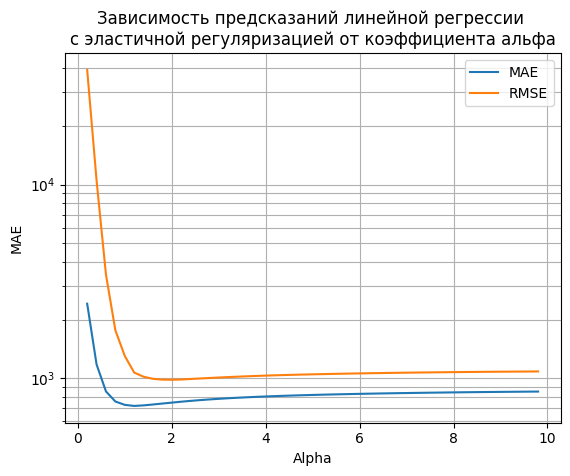

In [71]:
mod_err = [elem[0] for elem in alpha_results]
rmse_err = [elem[1] for elem in alpha_results]

plt.plot(arr_alpha,mod_err,)
plt.plot(arr_alpha,rmse_err,)

plt.title(label='Зависимость предсказаний линейной регрессии \nс эластичной регуляризацией от коэффициента альфа')
plt.ylabel("MAE")
plt.xlabel('Alpha')
plt.yscale('log')
plt.legend(['MAE','RMSE','R2'])
plt.grid(True, which="both", ls="-") # Сетка помогает видеть масштаб
plt.show()

## 9. Native models

Calculate the mean and median metrics from the previous lesson and add the results to the final dataframe.

In [72]:
for name in ['naive_median','naive_mean']:

    if name=='naive_median':
        predict = y_train.median()
    else:
        predict = y_train.mean()
    y_ptr = [predict] * len(y_train)
    y_pte = [predict] * len(y_test)

    res_MAE = pd.Series({'model':name,
            'train':mean_absolute_error(y_train,y_ptr),
            'test':mean_absolute_error(y_test,y_pte)})

    res_RMSE = pd.Series({'model':name,
            'train':root_mean_squared_error(y_train,y_ptr),
            'test':root_mean_squared_error(y_test,y_pte)})

    res_R2 = pd.Series({'model':name,
            'train':r2_score(y_train,y_ptr),
            'test':r2_score(y_test,y_pte)})

    result_MAE.loc[len(result_MAE)] = res_MAE
    result_RMSE.loc[len(result_RMSE)] = res_RMSE
    result_R2.loc[len(result_R2)] = res_R2

## 10. Compare results

1. Print your final tables

In [73]:
result_MAE

,model,train,test
0,my_lr,592.948671,597.956652
1,my_lr_grad,592.908107,598.217975
2,sklearn_lr,592.948671,597.956652
3,my_L1_ridge,592.90832,598.218156
4,my_L2_lasso,593.010814,598.304568
5,my_elastic,592.969287,598.26912
6,sk_ridge,592.951685,597.959824
7,sk_lasso,593.218781,598.351205
8,sk_elastic,689.586092,692.629371
9,minmax_sk_ridge,593.286381,8603.69113


In [74]:
result_RMSE

,model,train,test
0,my_lr,784.605276,790.581556
1,my_lr_grad,784.762032,790.960986
2,sklearn_lr,784.605276,790.581556
3,my_L1_ridge,784.762048,790.96088
4,my_L2_lasso,784.745902,790.938476
5,my_elastic,784.750908,790.94599
6,sk_ridge,784.605282,790.581752
7,sk_lasso,784.789777,790.831658
8,sk_elastic,883.066044,887.678898
9,minmax_sk_ridge,784.638211,10786.228486


In [75]:
result_R2

,model,train,test
0,my_lr,0.512163,0.507732
1,my_lr_grad,0.511968,0.507259
2,sklearn_lr,0.512163,0.507732
3,my_L1_ridge,0.511968,0.507259
4,my_L2_lasso,0.511988,0.507287
5,my_elastic,0.511982,0.507278
6,sk_ridge,0.512163,0.507732
7,sk_lasso,0.511934,0.50742
8,sk_elastic,0.382042,0.379388
9,minmax_sk_ridge,0.512122,-90.632081


### Навернём графиков емае

In [76]:
result_MAE = result_MAE.sort_values(by='test')

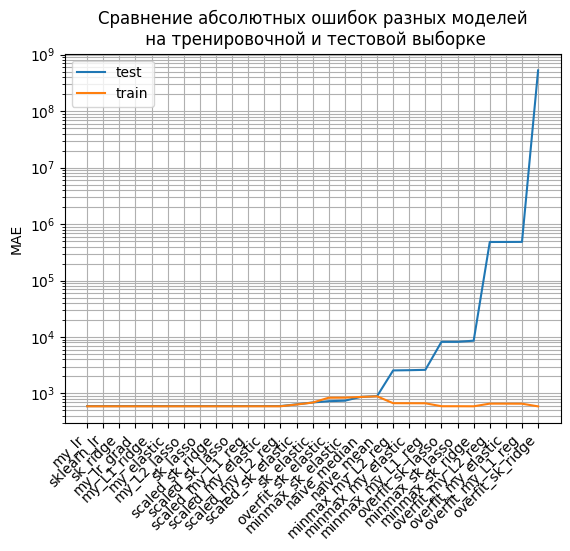

In [77]:
plt.Figure(figsize=(15,30))
plt.plot(result_MAE['model'],result_MAE['test'])
plt.plot(result_MAE['model'],result_MAE['train'])

plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="-") # Сетка помогает видеть масштаб
plt.ylabel('MAE')
plt.title('Сравнение абсолютных ошибок разных моделей\n на тренировочной и тестовой выборке')
plt.legend(['test','train'])

In [78]:
result_R2 = result_R2.sort_values(by='test',ascending=False)

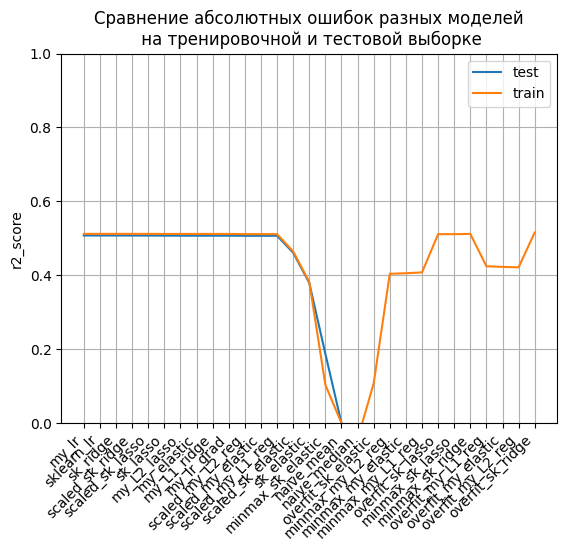

In [79]:
plt.Figure(figsize=(15,30))
plt.plot(result_R2['model'],result_R2['test'])
plt.plot(result_R2['model'],result_R2['train'])

# plt.yscale('log')
plt.ylim(0,1)
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="-") # Сетка помогает видеть масштаб
plt.ylabel('r2_score')
plt.title('Сравнение абсолютных ошибок разных моделей\n на тренировочной и тестовой выборке')
plt.legend(['test','train'])

In [80]:
result_RMSE = result_RMSE.sort_values(by='test',ascending=True)

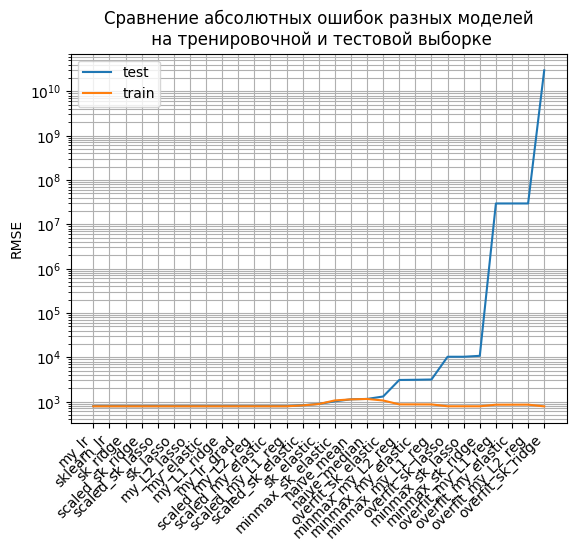

In [81]:
plt.Figure(figsize=(15,30))
plt.plot(result_RMSE['model'],result_RMSE['test'])
plt.plot(result_RMSE['model'],result_RMSE['train'])

plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.grid(True, which="both", ls="-") # Сетка помогает видеть масштаб
plt.ylabel('RMSE')
plt.title('Сравнение абсолютных ошибок разных моделей\n на тренировочной и тестовой выборке')
plt.legend(['test','train'])

2. What is the best model?


Лучшая модель ну хз, мало перебирал признаков

3. Which is the most stable model?

Самые стабильные модели - с регуляризацией

## ВОПРОС С СОБЕСЕДОВАНИЯ: КОНСТАНТНЫЕ КОЛОНКИ, ЗАЧЕМ ДРОПАТЬ? 

In [82]:
df.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,pre-war,roof deck,outdoor space,dining room,high speed internet,balcony,swimming pool,new construction,terrace,exclusive
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[dining room, pre-war, laundry in building, di...",40.7108,7170325,-73.9539,...,1,0,0,1,0,0,0,0,0,0
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[doorman, elevator, laundry in building, dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0,0,0,0
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[doorman, elevator, laundry in building, laund...",40.7575,7158677,-73.9625,...,0,0,0,0,0,0,0,0,0,0
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0,0,0,0
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[doorman, elevator, fitness center, laundry in...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0,0,0,0


In [83]:
import numpy as np
df_with_const = df.copy()
const_name = ['first_const','sec_const','third_const','fifth_const']
for const in const_name:
    value = np.random.random()
    df_with_const[const] = value

In [84]:
df_with_const.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,high speed internet,balcony,swimming pool,new construction,terrace,exclusive,first_const,sec_const,third_const,fifth_const
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[dining room, pre-war, laundry in building, di...",40.7108,7170325,-73.9539,...,0,0,0,0,0,0,0.676468,0.426351,0.01439,0.214057
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[doorman, elevator, laundry in building, dishw...",40.7513,7092344,-73.9722,...,0,0,0,0,0,0,0.676468,0.426351,0.01439,0.214057
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[doorman, elevator, laundry in building, laund...",40.7575,7158677,-73.9625,...,0,0,0,0,0,0,0.676468,0.426351,0.01439,0.214057
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,...,0,0,0,0,0,0,0.676468,0.426351,0.01439,0.214057
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[doorman, elevator, fitness center, laundry in...",40.7439,7225292,-73.9743,...,0,0,0,0,0,0,0.676468,0.426351,0.01439,0.214057


In [85]:
df_with_const.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44612 entries, 4 to 124009
Data columns (total 39 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   bathrooms            44612 non-null  float64
 1   bedrooms             44612 non-null  int64  
 2   building_id          44612 non-null  object 
 3   created              44612 non-null  object 
 4   description          44612 non-null  object 
 5   display_address      44612 non-null  object 
 6   features             44612 non-null  object 
 7   latitude             44612 non-null  float64
 8   listing_id           44612 non-null  int64  
 9   longitude            44612 non-null  float64
 10  manager_id           44612 non-null  object 
 11  photos               44612 non-null  object 
 12  price                44612 non-null  int64  
 13  street_address       44612 non-null  object 
 14  interest_level       44612 non-null  object 
 15  elevator             44612 non-null  int

In [86]:
list_of_object_col = df_with_const.select_dtypes(include='object')

In [87]:

X_const = df_with_const.drop(columns=list_of_object_col)
X_const = X_const.drop(columns=['price','listing_id'])
y_const = df_with_const['price']
X_train_const,X_test_const,y_train,y_test = train_test_split(X_const,y_const,test_size=0.2,random_state=21)

X_train = X_train_const.drop(columns = const_name)
X_test = X_test_const.drop(columns = const_name)

model_const = LinearRegression()
model_const.fit(X_train_const,y_train)
y_pred_const = model_const.predict(X_test_const)

model_no_const = LinearRegression()
model_no_const.fit(X_train,y_train)
y_pred = model_no_const.predict(X_test)

In [88]:
RMSE_const = root_mean_squared_error(y_pred=y_pred_const,y_true=y_test)
RMSE_no_const = root_mean_squared_error(y_pred=y_pred,y_true=y_test)

In [89]:
print(f'СКО ПРЕДСКАЗНИЙ С КОНСТ {RMSE_const:.4f}')
print(f'СКО ПРЕДСКАЗНИЙ БЕЗ КОНСТ {RMSE_no_const:.4f}')

СКО ПРЕДСКАЗНИЙ С КОНСТ 790.8797
СКО ПРЕДСКАЗНИЙ БЕЗ КОНСТ 790.8797


## ЛУЧШЕ ЛИ ПРОГНОЗИРУЕТ МОДЕЛЬ НА ЛОГОРИФМИРОВАННЫХ ЦЕНАХ???

In [90]:
y_train_log = np.log(y_train)

model = LinearRegression()
model.fit(X_train,y_train_log)
y_pred_log = model.predict(X_test)
y_pred = np.exp(y_pred_log)

RMSE_log = root_mean_squared_error(y_pred=y_pred,y_true=y_test)
print(f'СКО ПРЕДСКАЗНИЙ С ЛОГОРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: {RMSE_log:.4f}')
R2_s = r2_score(y_pred=y_pred,y_true=y_test)
print(f'СКО ПРЕДСКАЗНИЙ С ЛОГОРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: {R2_s:.4f}')

СКО ПРЕДСКАЗНИЙ С ЛОГОРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: 797.0218
СКО ПРЕДСКАЗНИЙ С ЛОГОРИФМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ: 0.5005


Логарифмирование: Это отличный прием, если данные имеют «тяжелый хвост» (skewness) или вы хотите минимизировать относительную, а не абсолютную ошибку.

<Axes: xlabel='price', ylabel='Count'>

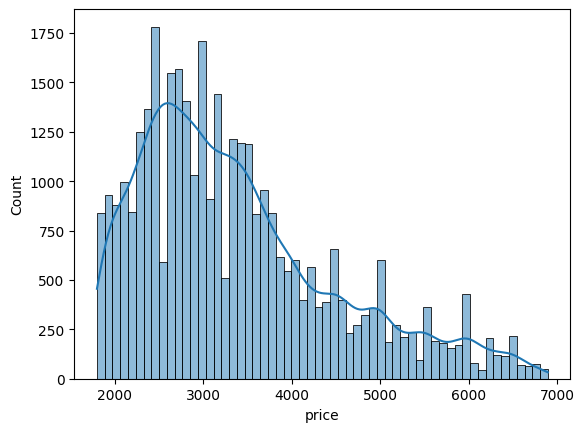

In [91]:
sns.histplot(y_train,kde=True)

In [92]:
y_train.skew()

np.float64(0.9383678169779203)

In [93]:
print('Умеренный перекос')

Умеренный перекос


Text(0.5, 1.0, 'Отлогорифмированная цена')

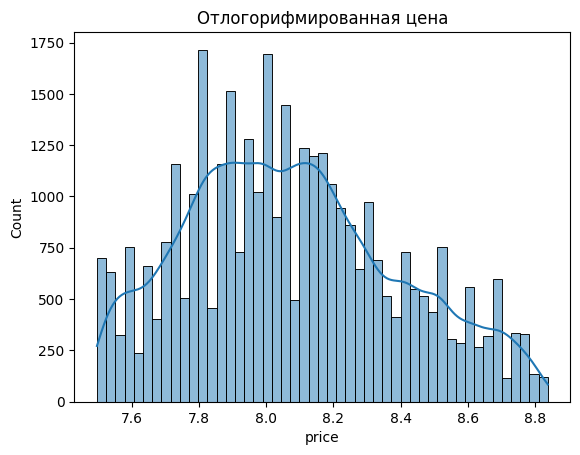

In [94]:
sns.histplot(y_train_log, kde = True)
plt.title('Отлогорифмированная цена')

In [95]:
y_train_log.skew()

np.float64(0.317496123388721)

In [96]:
if y_train.mean() > y_train.median():
    print('Перекос в право, среднее больше медианы')
else:
    print('Перекос в лево, медина больше среднего')

Перекос в право, среднее больше медианы
